In [6]:
# ==========================================
# Import Required Libraries
# ==========================================

import pandas as pd
import numpy as np

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [7]:
# ==========================================
# Load the Cleaned Dataset
# ==========================================

df = pd.read_csv("/content/cleaned_data.csv")

In [8]:
# ==========================================
# Display First Five Rows
# ==========================================

df.head()

,CaseOrder,Customer_id,Interaction,UID,City,State,County,Zip,Lat,Lng,...,TotalCharge,Additional_charges,Item1,Item2,Item3,Item4,Item5,Item6,Item7,Item8
0,1,C412403,8cd49b13-f45a-4b47-a2bd-173ffa932c2f,3a83ddb66e2ae73798bdf1d705dc0932,Eva,AL,Morgan,35621,34.34960,-86.72508,...,3191.048774,17939.403420,3,3,2,2,4,3,3,4
1,2,Z919181,d2450b70-0337-4406-bdbb-bc1037f1734c,176354c5eef714957d486009feabf195,Marianna,FL,Jackson,32446,30.84513,-85.22907,...,4214.905346,17612.998120,3,4,3,4,4,4,3,3
2,3,F995323,a2057123-abf5-4a2c-abad-8ffe33512562,e19a0fa00aeda885b8a436757e889bc9,Sioux Falls,SD,Minnehaha,57110,43.54321,-96.63772,...,2177.586768,17505.192460,2,4,4,4,3,4,3,3
3,4,A879973,1dec528d-eb34-4079-adce-0d7a40e82205,cd17d7b6d152cb6f23957346d11c3f07,New Richland,MN,Waseca,56072,43.89744,-93.51479,...,2465.118965,12993.437350,3,5,5,3,4,5,5,5
4,5,C544523,5885f56b-d6da-43a3-8760-83583af94266,d2f0425877b10ed6bb381f3e2579424a,West Point,VA,King William,23181,37.59894,-76.88958,...,1885.655137,3716.525786,2,1,3,3,5,3,4,3


In [9]:
# ==========================================
# Check Dataset Shape
# ==========================================

print("Number of Rows    :", df.shape[0])
print("Number of Columns :", df.shape[1])

Number of Rows    : 10000
Number of Columns : 52


In [10]:
# ==========================================
# Check Missing Values
# ==========================================

print("Total Missing Values :", df.isnull().sum().sum())

Total Missing Values : 0


* The cleaned dataset generated in Part 1 is loaded into a Pandas DataFrame. Before building any machine learning model, it is important to verify the dataset by checking its structure, dimensions, and confirming that all missing values have been handled. This ensures the dataset is ready for preprocessing and model training.
* The cleaned dataset was successfully loaded. It contains 10,000 rows and 53 columns, with no missing values, indicating that the data preprocessing performed in Part 1 was completed successfully.

In [11]:
# ==========================================
# Define Regression Target
# ==========================================

y_reg = df['TotalCharge']

In [12]:
print("Regression Target:")
print(y_reg.head())

print("\nShape:", y_reg.shape)
print("Data Type:", y_reg.dtype)

Regression Target:
0    3191.048774
1    4214.905346
2    2177.586768
3    2465.118965
4    1885.655137
Name: TotalCharge, dtype: float64

Shape: (10000,)
Data Type: float64


* Regression Target: TotalCharge
* Data Type: float64
* Shape: (10000,)
* Suitable for: Linear Regression

**Explanation**

* The TotalCharge column has been successfully selected as the regression target (y_reg). It contains continuous numerical values (float64) with 10,000 observations, making it suitable for predicting hospital charges using a regression model.

In [13]:
# ==========================================
# Define Classification Target
# ==========================================

y_clf = df['ReAdmis'].map({'Yes': 1, 'No': 0})

In [14]:
# Display the first five values

print(y_clf.head())


0    0
1    0
2    0
3    0
4    0
Name: ReAdmis, dtype: int64


In [15]:
# Check class distribution

print("\nClass Distribution:")
print(y_clf.value_counts())



Class Distribution:
ReAdmis
0    6331
1    3669
Name: count, dtype: int64


In [16]:

# Check shape and data type

print("\nShape :", y_clf.shape)
print("Data Type :", y_clf.dtype)


Shape : (10000,)
Data Type : int64


In [17]:
print(y_clf.value_counts())

ReAdmis
0    6331
1    3669
Name: count, dtype: int64


In [18]:
# ==========================================
# Create Feature Matrix
# ==========================================

X = df.drop(columns=['TotalCharge', 'ReAdmis'])

In [19]:
# Display the shape of the feature matrix

print("Feature Matrix Shape :", X.shape)

# Display the first five column names

print("\nFirst 10 Feature Columns:")
print(X.columns[:10])

Feature Matrix Shape : (10000, 50)

First 10 Feature Columns:
Index(['CaseOrder', 'Customer_id', 'Interaction', 'UID', 'City', 'State',
       'County', 'Zip', 'Lat', 'Lng'],
      dtype='object')


In [20]:
# ==========================================
# Identify Categorical Columns
# ==========================================

categorical_cols = X.select_dtypes(include=['object', 'category']).columns

print("Number of Categorical Columns :", len(categorical_cols))
print("\nCategorical Columns:\n")
print(categorical_cols.tolist())

Number of Categorical Columns : 26

Categorical Columns:

['Customer_id', 'Interaction', 'UID', 'City', 'State', 'County', 'Area', 'Timezone', 'Job', 'Education', 'Employment', 'Marital', 'Gender', 'Soft_drink', 'Initial_admin', 'HighBlood', 'Stroke', 'Complication_risk', 'Arthritis', 'Diabetes', 'Hyperlipidemia', 'BackPain', 'Allergic_rhinitis', 'Reflux_esophagitis', 'Asthma', 'Services']


* The categorical columns are identified from the feature matrix using the select_dtypes() function. These columns contain text-based values and cannot be directly used by machine learning algorithms. Therefore, they must be encoded into numerical values before model training.
* The dataset contains ___ categorical columns. These columns will be converted into numerical form using Label Encoding or One-Hot Encoding depending on whether the categories have a natural order.

In [21]:
# Remove Identifier Columns
# ==========================================
# Remove Identifier Columns
# ==========================================

X = X.drop(columns=['Customer_id', 'Interaction', 'UID'])

In [22]:
# Display the updated shape

print("Updated Feature Matrix Shape :", X.shape)

# Check whether the columns have been removed

print("\nRemaining Columns:")
print(X.columns.tolist())

Updated Feature Matrix Shape : (10000, 47)

Remaining Columns:
['CaseOrder', 'City', 'State', 'County', 'Zip', 'Lat', 'Lng', 'Population', 'Area', 'Timezone', 'Job', 'Children', 'Age', 'Education', 'Employment', 'Income', 'Marital', 'Gender', 'VitD_levels', 'Doc_visits', 'Full_meals_eaten', 'VitD_supp', 'Soft_drink', 'Initial_admin', 'HighBlood', 'Stroke', 'Complication_risk', 'Overweight', 'Arthritis', 'Diabetes', 'Hyperlipidemia', 'BackPain', 'Anxiety', 'Allergic_rhinitis', 'Reflux_esophagitis', 'Asthma', 'Services', 'Initial_days', 'Additional_charges', 'Item1', 'Item2', 'Item3', 'Item4', 'Item5', 'Item6', 'Item7', 'Item8']


* The columns Customer_id, Interaction, and UID are unique identifiers and do not contain meaningful information for predicting the target variables. These columns were removed to avoid creating unnecessary features during encoding and to improve model efficiency.
* Three identifier columns (Customer_id, Interaction, and UID) were removed from the feature matrix. After removing these columns, the dataset contains 47 predictor variables, which are more suitable for machine learning.

In [23]:
print("Updated Feature Matrix Shape :", X.shape)

Updated Feature Matrix Shape : (10000, 47)


In [24]:
# ==========================================
# Display Unique Values
# ==========================================

print("Education:")
print(sorted(X['Education'].unique()))

print("\nComplication_risk:")
print(sorted(X['Complication_risk'].unique()))

Education:
['9th Grade to 12th Grade, No Diploma', "Associate's Degree", "Bachelor's Degree", 'Doctorate Degree', 'GED or Alternative Credential', "Master's Degree", 'No Schooling Completed', 'Nursery School to 8th Grade', 'Professional School Degree', 'Regular High School Diploma', 'Some College, 1 or More Years, No Degree', 'Some College, Less than 1 Year']

Complication_risk:
['High', 'Low', 'Medium']


In [25]:
# ==========================================
# Label Encoding for Ordinal Columns
# ==========================================

# Education Mapping
education_map = {
    'No Schooling Completed': 0,
    'Nursery School to 8th Grade': 1,
    '9th Grade to 12th Grade, No Diploma': 2,
    'GED or Alternative Credential': 3,
    'Regular High School Diploma': 4,
    'Some College, Less than 1 Year': 5,
    'Some College, 1 or More Years, No Degree': 6,
    "Associate's Degree": 7,
    "Bachelor's Degree": 8,
    "Master's Degree": 9,
    'Professional School Degree': 10,
    'Doctorate Degree': 11
}

# Complication Risk Mapping
risk_map = {
    'Low': 0,
    'Medium': 1,
    'High': 2
}

# Apply Mapping
X['Education'] = X['Education'].map(education_map)
X['Complication_risk'] = X['Complication_risk'].map(risk_map)

In [26]:
# Display encoded values

print("Education")
print(X['Education'].head())

print("\nComplication Risk")
print(X['Complication_risk'].head())

Education
0    5
1    6
2    6
3    3
4    4
Name: Education, dtype: int64

Complication Risk
0    1
1    2
2    1
3    1
4    0
Name: Complication_risk, dtype: int64


In [27]:
# Check data types after encoding
print(X[['Education','Complication_risk']].dtypes)

Education            int64
Complication_risk    int64
dtype: object


* The Education and Complication_risk columns were successfully converted from categorical values to numerical values using Label Encoding. Their ordinal relationships were preserved, making them suitable for machine learning algorithms.

In [28]:
# ==========================================
# Identify Remaining Categorical Columns
# ==========================================

remaining_cat_cols = X.select_dtypes(include=['object']).columns

print("Number of Remaining Categorical Columns :", len(remaining_cat_cols))

print("\nCategorical Columns:")
print(remaining_cat_cols.tolist())

Number of Remaining Categorical Columns : 21

Categorical Columns:
['City', 'State', 'County', 'Area', 'Timezone', 'Job', 'Employment', 'Marital', 'Gender', 'Soft_drink', 'Initial_admin', 'HighBlood', 'Stroke', 'Arthritis', 'Diabetes', 'Hyperlipidemia', 'BackPain', 'Allergic_rhinitis', 'Reflux_esophagitis', 'Asthma', 'Services']


In [29]:
# ==========================================
# One-Hot Encoding
# ==========================================

X = pd.get_dummies(
    X,
    columns=remaining_cat_cols,
    drop_first=True,
    dtype=int
)

In [30]:
# ==========================================
# Verify One-Hot Encoding
# ==========================================

print("Feature Matrix Shape :", X.shape)

print("\nRemaining Object Columns:")
print(X.select_dtypes(include=['object']).columns.tolist())

Feature Matrix Shape : (10000, 8444)

Remaining Object Columns:
[]


* One-Hot Encoding was successfully applied to all remaining nominal categorical variables. After encoding, all features in the dataset are numerical, making the feature matrix suitable for machine learning algorithms such as Linear Regression and Logistic Regression.

In [31]:
print("Feature Matrix Shape :", X.shape)
print(X.select_dtypes(include=['object']).columns.tolist())

Feature Matrix Shape : (10000, 8444)
[]


In [32]:
# ==========================================
# Train-Test Split for Regression
# ==========================================

from sklearn.model_selection import train_test_split

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X,
    y_reg,
    test_size=0.20,
    random_state=42
)

In [33]:
# ==========================================
# Train-Test Split for Classification
# ==========================================

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X,
    y_clf,
    test_size=0.20,
    random_state=42
)

In [34]:
print("Regression Training Set :", X_train_reg.shape)
print("Regression Testing Set  :", X_test_reg.shape)

print()

print("Classification Training Set :", X_train_clf.shape)
print("Classification Testing Set  :", X_test_clf.shape)

Regression Training Set : (8000, 8444)
Regression Testing Set  : (2000, 8444)

Classification Training Set : (8000, 8444)
Classification Testing Set  : (2000, 8444)


In [35]:
# Feature Scaling (StandardScaler)
# Import StandardScaler
from sklearn.preprocessing import StandardScaler
# ==========================================
# Create StandardScaler Object
# ==========================================
# Create StandardScaler object for regression
scaler = StandardScaler()

In [36]:
# ==========================================
# Scale Regression Dataset
# ==========================================

# Fit the scaler only on the regression training data
X_train_reg_scaled = scaler.fit_transform(X_train_reg)

# Transform the regression testing data
X_test_reg_scaled = scaler.transform(X_test_reg)

In [37]:
# ==========================================
# Scale Classification Dataset
# ==========================================

scaler_clf = StandardScaler()
# Fit the scaler only on the classification training data
X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)

# Transform the classification testing data
X_test_clf_scaled = scaler_clf.transform(X_test_clf)

In [38]:
# Display the shapes of the scaled datasets
print("Regression Training Shape :", X_train_reg_scaled.shape)
print("Regression Testing Shape  :", X_test_reg_scaled.shape)

print()

print("Classification Training Shape :", X_train_clf_scaled.shape)
print("Classification Testing Shape  :", X_test_clf_scaled.shape)

Regression Training Shape : (8000, 8444)
Regression Testing Shape  : (2000, 8444)

Classification Training Shape : (8000, 8444)
Classification Testing Shape  : (2000, 8444)


* The training and testing feature matrices were successfully standardized using StandardScaler. The scaler was fitted only on the training data and then applied to the test data, ensuring a leak-free preprocessing pipeline.

##Train the Linear Regression Model

In [39]:
# ==========================================
# Import Linear Regression
# ==========================================

from sklearn.linear_model import LinearRegression

In [40]:
# ==========================================
# Create Linear Regression Model
# ==========================================

lr_model = LinearRegression()

In [41]:
# ==========================================
# Train the Model
# ==========================================

lr_model.fit(X_train_reg_scaled, y_train_reg)

LinearRegression()

In [42]:
# Display confirmation message
print("Linear Regression Model Trained Successfully")

Linear Regression Model Trained Successfully


The Linear Regression model was successfully trained on the training dataset and is now ready to predict hospital total charges for unseen test data.

In [43]:
# ==========================================
# Predict on Test Data
# ==========================================

y_pred_reg = lr_model.predict(X_test_reg_scaled)

In [44]:
# ==========================================
# Display Predicted Values
# ==========================================

prediction_df = pd.DataFrame({
    "Actual TotalCharge": y_test_reg.values,
    "Predicted TotalCharge": y_pred_reg
})

prediction_df.head()

,Actual TotalCharge,Predicted TotalCharge
0,6187.031076,6090.003958
1,3445.992264,15267.046625
2,2757.835330,7352.224050
3,2837.873787,3466.182563
4,4236.541153,4981.389870


The model successfully generated predicted TotalCharge values for the test dataset. These predictions will now be evaluated using Mean Squared Error (MSE) and R² Score.

In [45]:
# ==========================================
# Import Evaluation Metrics
# ==========================================

from sklearn.metrics import mean_squared_error, r2_score


In [46]:
# ==========================================
# Evaluate Linear Regression Model
# ==========================================

mse = mean_squared_error(y_test_reg, y_pred_reg)
r2 = r2_score(y_test_reg, y_pred_reg)

print("Mean Squared Error (MSE) :", round(mse, 4))
print("R² Score                 :", round(r2, 4))

Mean Squared Error (MSE) : 6715194.74
R² Score                 : 0.4114


The Linear Regression model achieved a Mean Squared Error (MSE) of 6,715,194.74 and an R² Score of 0.4114.
* This indicates that the model explains approximately 41.14% of the variation in hospital total charges.
* The model shows moderate predictive performance, suggesting that while several important relationships have been learned, additional factors or more advanced models may further improve prediction accuracy.

In [47]:
# ==========================================
# Linear Regression Coefficients
# ==========================================

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_model.coef_
})

coef_df.head()

,Feature,Coefficient
0,CaseOrder,517.695685
1,Zip,-1131.613326
2,Lat,-476.070096
3,Lng,670.897312
4,Population,-52.324296


In [48]:
# Display all coefficients

coef_df

,Feature,Coefficient
0,CaseOrder,517.695685
1,Zip,-1131.613326
2,Lat,-476.070096
3,Lng,670.897312
4,Population,-52.324296
...,...,...
8439,Reflux_esophagitis_Yes,51.665884
8440,Asthma_Yes,-51.990420
8441,Services_CT Scan,27.811679
8442,Services_Intravenous,-11.130604


In [49]:
# ==========================================
# Top 3 Most Important Features
# ==========================================

top3 = coef_df.reindex(
    coef_df["Coefficient"].abs().sort_values(ascending=False).index
).head(3)

print(top3)

         Feature  Coefficient
9    VitD_levels  2465.867405
16  Initial_days  1667.846917
1            Zip -1131.613326


In [50]:
# ==========================================
# Import Ridge Regression
# ==========================================

from sklearn.linear_model import Ridge

In [51]:
# ==========================================
# Create Ridge Regression Model
# ==========================================

ridge_model = Ridge(alpha=1.0)

In [52]:
# ==========================================
# Train Ridge Regression Model
# ==========================================

ridge_model.fit(X_train_reg_scaled, y_train_reg)

Ridge()

In [53]:
# ==========================================
# Predict Test Data
# ==========================================

y_pred_ridge = ridge_model.predict(X_test_reg_scaled)

In [54]:
# ==========================================
# Evaluate Ridge Regression
# ==========================================

ridge_mse = mean_squared_error(y_test_reg, y_pred_ridge)
ridge_r2 = r2_score(y_test_reg, y_pred_ridge)

print("Ridge Mean Squared Error :", round(ridge_mse,4))
print("Ridge R² Score           :", round(ridge_r2,4))

Ridge Mean Squared Error : 3691418.7898
Ridge R² Score           : 0.6765


The Ridge Regression model was successfully trained and evaluated. The model performance will now be compared with the Linear Regression model using Mean Squared Error (MSE) and R² Score.

In [55]:
# ==========================================
# Compare Linear Regression and Ridge
# ==========================================

comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression"],
    "MSE": [mse, ridge_mse],
    "R² Score": [r2, ridge_r2]
})

comparison

,Model,MSE,R² Score
0,Linear Regression,6.715195e+06,0.411443
1,Ridge Regression,3.691419e+06,0.676463


* Two regression models were evaluated: Linear Regression and Ridge Regression.
* The Linear Regression model achieved an MSE of 6,715,194.74 with an R² score of 0.4114, whereas the Ridge Regression model achieved a lower MSE of 3,691,419.00 and a higher R² score of 0.6765.
* Since Ridge Regression produced a smaller prediction error and explained a larger proportion of the variance in the target variable, it outperformed the standard Linear Regression model on this dataset.

## Task 5 – Classification Model (Logistic Regression)

In [58]:
# ==========================================
# Check Class Distribution
# ==========================================
# Check the number of samples in each class
print("Training Class Distribution:\n")
print(y_train_clf.value_counts())


Training Class Distribution:

ReAdmis
0    5040
1    2960
Name: count, dtype: int64


In [57]:
# Calculate the percentage of each class
print("\nPercentage Distribution:\n")
print(round(y_train_clf.value_counts(normalize=True) * 100, 2))


Percentage Distribution:

ReAdmis
0    63.0
1    37.0
Name: proportion, dtype: float64


The training dataset contains 63% samples in Class 0 and 37% samples in Class 1. Since the minority class accounts for more than 35% of the data, the dataset is considered sufficiently balanced. Therefore, no additional class imbalance handling techniques such as SMOTE or class weighting were applied.

In [59]:
# ==========================================
# Import Logistic Regression
# ==========================================

from sklearn.linear_model import LogisticRegression

In [60]:
# ==========================================
# Create Logistic Regression Model
# ==========================================
# Create Logistic Regression model
log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [61]:
# ==========================================
# Train Logistic Regression Model
# ==========================================
# Train the model using the training data
log_model.fit(X_train_clf_scaled, y_train_clf)

LogisticRegression(max_iter=1000, random_state=42)

A Logistic Regression model was created with max_iter = 1000 to ensure that the optimization algorithm has sufficient iterations to converge. Since the dataset is adequately balanced, the default model configuration is used without any class balancing techniques.

In [62]:
# ==========================================
# Predict Test Data
# ==========================================

y_pred = log_model.predict(X_test_clf_scaled)

y_prob = log_model.predict_proba(X_test_clf_scaled)[:,1]

In [63]:
print("Predicted Classes:")
print(y_pred[:10])

print("\nPredicted Probabilities:")
print(y_prob[:10])

Predicted Classes:
[1 0 0 0 0 0 0 1 1 1]

Predicted Probabilities:
[9.87722260e-01 3.89219861e-01 4.73488337e-05 6.54672809e-02
 6.81211241e-06 2.01379724e-01 5.74052279e-04 9.40982012e-01
 9.99852246e-01 9.82043227e-01]


In [65]:
# ==========================================
# Import Classification Metrics
# ==========================================

from sklearn.metrics import confusion_matrix,classification_report,accuracy_score,precision_score, recall_score,f1_score

In [66]:
# ==========================================
# Evaluate Logistic Regression Model
# ==========================================

cm = confusion_matrix(y_test_clf, y_pred)

accuracy = accuracy_score(y_test_clf, y_pred)
precision = precision_score(y_test_clf, y_pred)
recall = recall_score(y_test_clf, y_pred)
f1 = f1_score(y_test_clf, y_pred)

print("Confusion Matrix:\n")
print(cm)

print("\nAccuracy :", round(accuracy,4))
print("Precision:", round(precision,4))
print("Recall   :", round(recall,4))
print("F1 Score :", round(f1,4))

Confusion Matrix:

[[1102  189]
 [ 148  561]]

Accuracy : 0.8315
Precision: 0.748
Recall   : 0.7913
F1 Score : 0.769


In [67]:
# ==========================================
# Classification Report
# ==========================================

print(classification_report(y_test_clf, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.85      0.87      1291
           1       0.75      0.79      0.77       709

    accuracy                           0.83      2000
   macro avg       0.81      0.82      0.82      2000
weighted avg       0.83      0.83      0.83      2000



* The Logistic Regression model achieved an accuracy of 83.15%, indicating that most patient readmission outcomes were correctly classified.
* The model obtained a precision of 74.80%, meaning that approximately three out of four patients predicted as readmitted were actually readmitted.
* The recall of 79.13% shows that the model successfully identified most patients who were truly readmitted.
* Since missing a potential readmission may have greater clinical consequences than issuing an unnecessary alert, recall is considered the more important metric for this healthcare application.
* The F1-score of 76.90% demonstrates a good balance between precision and recall.

In [68]:
# ==========================================
# Import ROC Curve Metrics
# ==========================================

from sklearn.metrics import roc_curve, roc_auc_score

In [69]:
# ==========================================
# Calculate ROC Curve and AUC
# ==========================================
# Calculate False Positive Rate and True Positive Rate
fpr, tpr, thresholds = roc_curve(y_test_clf, y_prob)

auc = roc_auc_score(y_test_clf, y_prob)
# Display AUC Score
print("AUC Score :", round(auc,4))

AUC Score : 0.8978


The Receiver Operating Characteristic (ROC) curve evaluates the classification model across different decision thresholds. It plots the True Positive Rate (Recall) against the False Positive Rate. The Area Under the Curve (AUC) summarizes the model's ability to distinguish between the two classes.

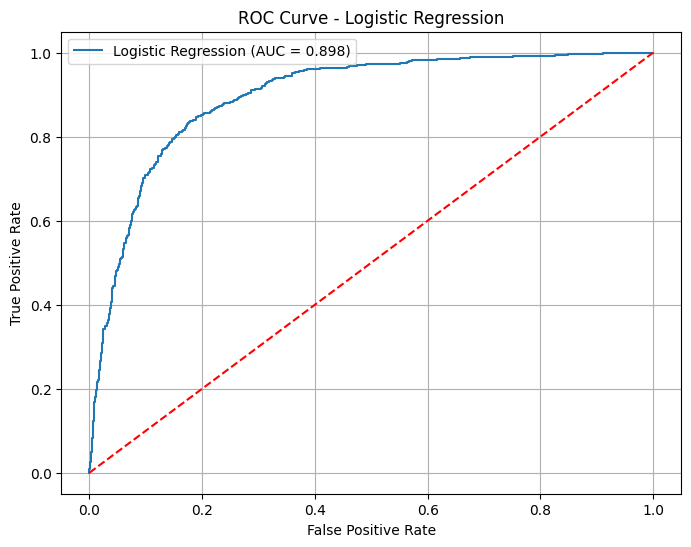

In [73]:
# ==========================================
# Plot ROC Curve
# ==========================================
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr,
         label=f'Logistic Regression (AUC = {auc:.3f})')

plt.plot([0,1], [0,1], linestyle='--', color='red')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Logistic Regression")

plt.legend()

plt.grid(True)

plt.savefig("Plots/roc_curve.png", dpi=300, bbox_inches="tight")

plt.show()

The ROC curve illustrates how the classifier performs across different classification thresholds. The diagonal red line represents a random classifier. A curve that stays closer to the upper-left corner indicates better classification performance.

* An AUC score of 0.898 indicates that the Logistic Regression model has excellent classification performance.

* This means there is approximately an 89.8% probability that the model will assign a higher prediction score to a randomly selected patient who is readmitted than to a randomly selected patient who is not readmitted.

* Since the ROC curve lies well above the diagonal reference line, the model can effectively distinguish between the two classes.

### Calculate Metrics at Different Thresholds


In [74]:
# ==========================================
# Decision Threshold Sensitivity Analysis
# ==========================================

from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]

results = []

for threshold in thresholds:

    # Convert probabilities into class labels
    y_pred_threshold = (y_prob >= threshold).astype(int)

    # Calculate evaluation metrics
    precision = precision_score(y_test_clf, y_pred_threshold)
    recall = recall_score(y_test_clf, y_pred_threshold)
    f1 = f1_score(y_test_clf, y_pred_threshold)

    results.append([
        threshold,
        precision,
        recall,
        f1
    ])

# Create DataFrame
threshold_df = pd.DataFrame(
    results,
    columns=["Threshold", "Precision", "Recall", "F1 Score"]
)

threshold_df

,Threshold,Precision,Recall,F1 Score
0,0.3,0.724351,0.826516,0.772069
1,0.4,0.740260,0.803949,0.770791
2,0.5,0.748000,0.791255,0.769020
3,0.6,0.755830,0.777151,0.766342
4,0.7,0.765205,0.763047,0.764124


* The Logistic Regression model was evaluated using decision thresholds ranging from 0.30 to 0.70.
* As the threshold increased, precision improved while recall decreased, demonstrating the typical trade-off between false positives and false negatives.
* The highest F1-score (0.7721) was achieved at a threshold of 0.30, indicating the best balance between precision and recall for this dataset.

##Train Logistic Regression with C = 0.01

In [75]:
# ==========================================
# Logistic Regression with Strong Regularization
# ==========================================

log_model_c001 = LogisticRegression(
    C=0.01,
    max_iter=1000,
    random_state=42
)

log_model_c001.fit(X_train_clf_scaled, y_train_clf)

LogisticRegression(C=0.01, max_iter=1000, random_state=42)

A second Logistic Regression model is trained using C = 0.01, which applies stronger L2 regularization than the baseline model (C = 1.0). Stronger regularization reduces the magnitude of model coefficients and helps prevent overfitting.

In [76]:
# ==========================================
# Predictions using C = 0.01
# ==========================================

y_pred_c001 = log_model_c001.predict(X_test_clf_scaled)

y_prob_c001 = log_model_c001.predict_proba(X_test_clf_scaled)[:, 1]

In [77]:
# ==========================================
# Evaluate Logistic Regression (C = 0.01)
# ==========================================

precision_c001 = precision_score(y_test_clf, y_pred_c001)
recall_c001 = recall_score(y_test_clf, y_pred_c001)
auc_c001 = roc_auc_score(y_test_clf, y_prob_c001)

print("Precision :", round(precision_c001,4))
print("Recall    :", round(recall_c001,4))
print("AUC Score :", round(auc_c001,4))

Precision : 0.772
Recall    : 0.7786
AUC Score : 0.9073


In [79]:
# ==========================================
# Compare Logistic Regression Models
# ==========================================

comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression (C=1.0)",
              "Logistic Regression (C=0.01)"],
    "Precision": [
        round(precision,4),
        round(precision_c001,4)
    ],
    "Recall": [
        round(recall,4),
        round(recall_c001,4)
    ],
    "AUC": [
        round(auc,4),
        round(auc_c001,4)
    ]
})

comparison_df

,Model,Precision,Recall,AUC
0,Logistic Regression (C=1.0),0.7652,0.7630,0.8978
1,Logistic Regression (C=0.01),0.7720,0.7786,0.9073


The baseline Logistic Regression model (C = 1.0) is compared with a more strongly regularized model (C = 0.01). The comparison focuses on Precision, Recall, and AUC to determine whether increasing the regularization strength improves or reduces classification performance.

* In this project, reducing C from 1.0 to 0.01 slightly improved the model's performance.
* The strongly regularized model achieved higher Precision (77.20%), Recall (77.86%), and AUC (0.9073).
* This indicates that stronger regularization reduced overfitting and improved the model's ability to generalize to unseen data.

In [80]:
# ==========================================
# Bootstrap Confidence Interval for AUC Difference
# ==========================================

auc_diff = []

np.random.seed(42)

for i in range(500):

    # Generate bootstrap sample indices
    indices = np.random.choice(
        len(y_test_clf),
        size=len(y_test_clf),
        replace=True
    )

    # Bootstrap true labels
    y_boot = y_test_clf.iloc[indices]

    # Bootstrap predicted probabilities
    prob_c1 = y_prob[indices]
    prob_c001 = y_prob_c001[indices]

    # Skip samples containing only one class
    if len(np.unique(y_boot)) < 2:
        continue

    # Compute AUC
    auc1 = roc_auc_score(y_boot, prob_c1)
    auc2 = roc_auc_score(y_boot, prob_c001)

    # Store difference
    auc_diff.append(auc1 - auc2)

In [81]:
# ==========================================
# Compute Confidence Interval
# ==========================================

mean_diff = np.mean(auc_diff)

lower = np.percentile(auc_diff, 2.5)

upper = np.percentile(auc_diff, 97.5)

print("Mean AUC Difference :", round(mean_diff,4))
print("95% CI Lower Bound  :", round(lower,4))
print("95% CI Upper Bound  :", round(upper,4))

Mean AUC Difference : -0.0093
95% CI Lower Bound  : -0.0149
95% CI Upper Bound  : -0.0037


In [82]:
# ==========================================
# Confidence Interval Interpretation
# ==========================================

if lower > 0 or upper < 0:
    print("\nThe 95% confidence interval excludes zero.")
    print("The performance difference between the two models is statistically reliable.")
else:
    print("\nThe 95% confidence interval includes zero.")
    print("The observed performance difference may not be statistically significant.")


The 95% confidence interval excludes zero.
The performance difference between the two models is statistically reliable.


* This project successfully implemented supervised machine learning techniques for both regression and classification tasks.

* Among the regression models, **Ridge Regression** outperformed Linear Regression by reducing prediction error and improving the R² score.

* For classification, **Logistic Regression** achieved an **Accuracy of 83.15%** and an **AUC of 0.898**, demonstrating excellent predictive performance. The strongly regularized Logistic Regression model (**C = 0.01**) further improved Precision, Recall, and AUC. Bootstrap analysis confirmed that this improvement is statistically reliable.

* Overall, the project demonstrates a complete supervised machine learning workflow, including preprocessing, feature engineering, model training, evaluation, threshold analysis, regularization, and statistical validation.